In [1]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

In [2]:
LLM = ChatGroq(model="openai/gpt-oss-20b", temperature=0.7)

In [3]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description='Detailed feedback for the essay')
    score: int = Field(description='score out of 10', gt=0, le=10)
    

In [4]:
structured_model = LLM.with_structured_output(EvaluationSchema)

In [ ]:

essay = """
The Importance of Technology

Technology has become an essential part of our daily lives. It helps us communicate, learn, and work more efficiently. Modern innovations such as artificial intelligence and the internet have transformed many industries. However, technology should be used responsibly to protect privacy and maintain a healthy balance. When used wisely, it improves our quality of life and creates new opportunities for the future.


"""

In [ ]:
# sample testing
prompt = f"Evauate the language quality of th following essay and provide a feedback and assign a score out of 10 \n {essay}"

response = structured_model.invoke(prompt)

In [8]:
# sample testing
print(response)

feedback='The essay is clear and concise, with a logical structure that introduces the topic, outlines its benefits, and cautions about responsible use. The language is mostly correct, but a few areas could be improved: 1) Sentence variety – adding more complex sentences or varied structures would enhance readability. 2) Transition words – using phrases like ‘Moreover’ or ‘Nevertheless’ could strengthen the flow. 3) Specific examples – mentioning particular technologies or scenarios would add depth. Overall, it demonstrates solid language skills but could benefit from richer detail and smoother transitions.' score=8


In [9]:
# sample testing
response = structured_model.invoke(prompt).score

In [10]:
print(response)

7


In [22]:
# lets create our workflow
class UPSEState(TypedDict):
    
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add] # to prevent it from overwriting
    avg_score: float

In [23]:
def eval_language(state: UPSEState):
    prompt = f"Evauate the language qualityof the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)
    
    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

In [24]:
def eval_analysis(state: UPSEState):
    prompt=f"Evauate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)
    
    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

In [25]:
def eval_thought(state: UPSEState):
    prompt = f"Evauate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)
    
    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score] }

In [26]:
def eval_final(state: UPSEState):
    
    # summary feedback will be generated 
    prompt = f"based on the following feedbacks create a summarized feedback \n langauge feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of feedback - {state["clarity_feedback"]}"
    
    overall_feedback = LLM.invoke(prompt).content
    
    #  avg scores will be calculated
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])
    
    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [27]:
# building the graph
graph = StateGraph(UPSEState)

# adding the node to the graph
graph.add_node('evaluate_langauge', eval_language)
graph.add_node('evaluate_analysis', eval_analysis)
graph.add_node('evaluate_thought', eval_thought)
graph.add_node('final_evaluation', eval_final)

# now we will need the edges for the graph
graph.add_edge(START, 'evaluate_langauge')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_langauge', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)
    

In [28]:
workflow = graph.compile()

In [29]:
# executing
initial_state = {'essay': essay}
output_state = workflow.invoke(initial_state)

In [30]:
print(output_state)

{'essay': '\nThe Importance of Technology\n\nTechnology has become an essential part of our daily lives. It helps us communicate, learn, and work more efficiently. Modern innovations such as artificial intelligence and the internet have transformed many industries. However, technology should be used responsibly to protect privacy and maintain a healthy balance. When used wisely, it improves our quality of life and creates new opportunities for the future.\n\n\n', 'language_feedback': 'The essay is clear, concise, and well‑structured. It uses simple, correct grammar and appropriate vocabulary for a general audience. The sentences flow logically from one idea to the next, and the paragraph maintains a consistent focus on the role of technology. Minor improvements could include adding more specific examples or varied sentence length to increase engagement, and tightening the final sentence to avoid repetition. Overall, the language quality is strong and effective for its purpose.', 'analy

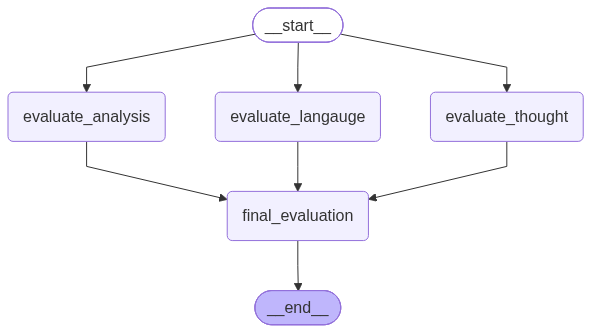

In [31]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())